In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Reading the Evaluation data by Pathologist

In [2]:
evaluator_id = 'evaluator3'
eval_data_path = f"input/{evaluator_id}/pathopen_eval_data.csv"
eval_data = pd.read_csv(eval_data_path)
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,Evaluation OE_Correct_Answer_1\n(Benchmark 1),Unnamed: 6,OE_Wrong_Answer_1,Evaluation OE_Wrong_Answer_1\n(Benchmark 2),Unnamed: 9,...,Unnamed: 26,MCQ_OE_Wrong_Answer_3,Evaluation MCQ_OE_Wrong_Answer_3\n(Benchmark 2),Unnamed: 29,MCQ_OE_Wrong_Answer_4,Evaluation MCQ_OE_Wrong_Answer_4\n(Benchmark 2),Unnamed: 32,CE_Question,CE_Correct_Answer,Evaluation CE_Correct_Answer\n(Benchmark 3)
0,NaN,NaN,NaN,NaN,NaN,Knowledge Interpretation/Deduction,Visual Grounding,NaN,Error Proximity/Deductive Plausibility,Visual Grounding Error,...,Visual Grounding Error,NaN,Error Proximity/Deductive Plausibility,Visual Grounding Error,NaN,Error Proximity/Deductive Plausibility,Visual Grounding Error,NaN,NaN,Visual Grounding/Reasoning
1,127.0,img_pathopen_127_03,https://drive.google.com/open?id=1Ap7zdKbExdkh...,How would one describe the abnormality represe...,The lesion is comprised of a mixture of small ...,2,2,The lesion is comprised of a mixture of small ...,0,0,...,1,The large open structure in the image represen...,0,0,The large open structure in the image represen...,1,1,Is the material within the large open structur...,Yes,2
2,79.0,img_pathopen_79_01,https://drive.google.com/open?id=1avNYoJeBGrCX...,How can the growth pattern for this dermal les...,The primary growth pattern for this spindle ce...,2,2,\nThe primary growth pattern for this spindle ...,1,0,...,0,The interface of the lesion is infiltrative wi...,0,0,The interface of the lesion is sharp with a de...,0,0,Does the image represent a benign neoplasm of ...,Yes,2
3,126.0,img_pathopen_126_01,https://drive.google.com/open?id=1ZeBueBr51LvU...,What abnormal growth pattern is depicted in th...,The image shows FIGO grade 1 endometrial adeno...,2,2,The image shows FIGO grade 1 endometrial adeno...,1,1,...,0,There is a hyperplastic and atypical glandular...,0,0,There is a hyperplastic and atypical glandular...,0,0,Does the image from a uterine tumor show the p...,No,2
4,27.0,img_pathopen_27_01,https://drive.google.com/open?id=16jp9EK7ij0p9...,The special structures depicted in this image ...,These are typical Verocay bodies depicted with...,2,2,NaN,NaN,NaN,...,0,Neurofibromatosis type 1,1,1,Peutz-Jegher syndrome,0,0,Are the typical features of malignant peripher...,No,2


Creating the directory structure to save Graphs and Output for Each Evaluator

In [3]:
output_data_path = f"output/{evaluator_id}"
os.makedirs(output_data_path, exist_ok=True)

Renaming some columns

In [4]:
eval_data = eval_data.rename(columns={'Evaluation OE_Correct_Answer_1\n(Benchmark 1)': 'OE_Correct_Answer_1_Know_Inter',
                                        'Unnamed: 6': 'OE_Correct_Answer_1_Vis_Ground',
                                        'Evaluation OE_Wrong_Answer_1\n(Benchmark 2)': 'OE_Wrong_Answer_1_Err_Prox',
                                        'Unnamed: 9': 'OE_Wrong_Answer_1_Vis_Ground',
                                        'Evaluation OE_Correct_Answer_2\n(Benchmark 1)': 'OE_Correct_Answer_2_Know_Inter',
                                        'Unnamed: 13': 'OE_Correct_Answer_2_Vis_Ground',
                                        'Evaluation OE_Wrong_Answer_2\n(Benchmark 2)': 'OE_Wrong_Answer_2_Err_Prox',
                                        'Unnamed: 16': 'OE_Wrong_Answer_2_Vis_Ground',
                                        'Evaluation MCQ_OE_Correct_Answer\n(Benchmark 1)': 'MCQ_OE_Correct_Answer_Know_Inter',
                                        'Unnamed: 20': 'MCQ_OE_Correct_Answer_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_1\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_1_Err_Prox',
                                        'Unnamed: 23': 'MCQ_OE_Wrong_Answer_1_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_2\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_2_Err_Prox',
                                        'Unnamed: 26': 'MCQ_OE_Wrong_Answer_2_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_3\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_3_Err_Prox',
                                        'Unnamed: 29': 'MCQ_OE_Wrong_Answer_3_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_4\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_4_Err_Prox',
                                        'Unnamed: 32': 'MCQ_OE_Wrong_Answer_4_Vis_Ground',
                                        'Evaluation CE_Correct_Answer\n(Benchmark 3)': 'CE_Correct_Answer_Vis_Ground',
                                        })

eval_data = eval_data.drop(index=0) #dropping the first row which contains the benchmark names
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,OE_Correct_Answer_1_Know_Inter,OE_Correct_Answer_1_Vis_Ground,OE_Wrong_Answer_1,OE_Wrong_Answer_1_Err_Prox,OE_Wrong_Answer_1_Vis_Ground,...,MCQ_OE_Wrong_Answer_2_Vis_Ground,MCQ_OE_Wrong_Answer_3,MCQ_OE_Wrong_Answer_3_Err_Prox,MCQ_OE_Wrong_Answer_3_Vis_Ground,MCQ_OE_Wrong_Answer_4,MCQ_OE_Wrong_Answer_4_Err_Prox,MCQ_OE_Wrong_Answer_4_Vis_Ground,CE_Question,CE_Correct_Answer,CE_Correct_Answer_Vis_Ground
1,127.0,img_pathopen_127_03,https://drive.google.com/open?id=1Ap7zdKbExdkh...,How would one describe the abnormality represe...,The lesion is comprised of a mixture of small ...,2,2,The lesion is comprised of a mixture of small ...,0,0,...,1,The large open structure in the image represen...,0,0,The large open structure in the image represen...,1,1,Is the material within the large open structur...,Yes,2
2,79.0,img_pathopen_79_01,https://drive.google.com/open?id=1avNYoJeBGrCX...,How can the growth pattern for this dermal les...,The primary growth pattern for this spindle ce...,2,2,\nThe primary growth pattern for this spindle ...,1,0,...,0,The interface of the lesion is infiltrative wi...,0,0,The interface of the lesion is sharp with a de...,0,0,Does the image represent a benign neoplasm of ...,Yes,2
3,126.0,img_pathopen_126_01,https://drive.google.com/open?id=1ZeBueBr51LvU...,What abnormal growth pattern is depicted in th...,The image shows FIGO grade 1 endometrial adeno...,2,2,The image shows FIGO grade 1 endometrial adeno...,1,1,...,0,There is a hyperplastic and atypical glandular...,0,0,There is a hyperplastic and atypical glandular...,0,0,Does the image from a uterine tumor show the p...,No,2
4,27.0,img_pathopen_27_01,https://drive.google.com/open?id=16jp9EK7ij0p9...,The special structures depicted in this image ...,These are typical Verocay bodies depicted with...,2,2,NaN,NaN,NaN,...,0,Neurofibromatosis type 1,1,1,Peutz-Jegher syndrome,0,0,Are the typical features of malignant peripher...,No,2
5,151.0,img_pathopen_151_03,https://drive.google.com/open?id=19KsfXwd-HtN_...,What is the organ and likely diagnosis from th...,"The image shows kidney cortex, as evidenced by...",2,2,"The image shows kidney cortex, as evidenced by...",1,2,...,2,This is end stage renal disease caused by muta...,0,1,This is end stage renal disease caused by muta...,0,1,Does the image from the kidney show hemorrhagi...,No,2


Converting all the evaluation columns from Str to Int

In [5]:
eval_data = eval_data.astype({'OE_Correct_Answer_1_Know_Inter': 'float',
                                'OE_Correct_Answer_1_Vis_Ground': 'float',
                                'OE_Wrong_Answer_1_Err_Prox': 'float',
                                'OE_Wrong_Answer_1_Vis_Ground': 'float',
                                'OE_Correct_Answer_2_Know_Inter': 'float',
                                'OE_Correct_Answer_2_Vis_Ground': 'float',
                                'OE_Wrong_Answer_2_Err_Prox': 'float',
                                'OE_Wrong_Answer_2_Vis_Ground': 'float',
                                'MCQ_OE_Correct_Answer_Know_Inter': 'float',
                                'MCQ_OE_Correct_Answer_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_1_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_1_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_2_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_2_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_3_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_3_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_4_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_4_Vis_Ground': 'float',
                                'CE_Correct_Answer_Vis_Ground': 'float',})

eval_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 1 to 46
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CASE_ID                           46 non-null     float64
 1   Image_ID                          46 non-null     str    
 2   Image_URL                         46 non-null     str    
 3   OE_Question_1                     46 non-null     str    
 4   OE_Correct_Answer_1               46 non-null     str    
 5   OE_Correct_Answer_1_Know_Inter    46 non-null     float64
 6   OE_Correct_Answer_1_Vis_Ground    46 non-null     float64
 7   OE_Wrong_Answer_1                 34 non-null     str    
 8   OE_Wrong_Answer_1_Err_Prox        34 non-null     float64
 9   OE_Wrong_Answer_1_Vis_Ground      34 non-null     float64
 10  OE_Question_2                     44 non-null     str    
 11  OE_Correct_Answer_2               44 non-null     str    
 12  OE_Correct_Answer_2_K

Finding Missing Evaluations or Wrong Evaluations

In [6]:
OE_Correct_Answer_1_Know_Inter_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Correct_Answer_1'].isnull()) & ((eval_data['OE_Correct_Answer_1_Know_Inter'].isnull()) | (~eval_data['OE_Correct_Answer_1_Know_Inter'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_1_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Correct_Answer_1'].isnull()) & ((eval_data['OE_Correct_Answer_1_Vis_Ground'].isnull()) | (~eval_data['OE_Correct_Answer_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_1_Err_Prox_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Wrong_Answer_1'].isnull()) & ((eval_data['OE_Wrong_Answer_1_Err_Prox'].isnull()) | (~eval_data['OE_Wrong_Answer_1_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_1_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Wrong_Answer_1'].isnull()) & ((eval_data['OE_Wrong_Answer_1_Vis_Ground'].isnull()) | (~eval_data['OE_Wrong_Answer_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Know_Inter_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Correct_Answer_2'].isnull()) & ((eval_data['OE_Correct_Answer_2_Know_Inter'].isnull()) | (~eval_data['OE_Correct_Answer_2_Know_Inter'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Correct_Answer_2'].isnull()) & ((eval_data['OE_Correct_Answer_2_Vis_Ground'].isnull()) | (~eval_data['OE_Correct_Answer_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_2_Err_Prox_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Wrong_Answer_2'].isnull()) & ((eval_data['OE_Wrong_Answer_2_Err_Prox'].isnull()) | (~eval_data['OE_Wrong_Answer_2_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_2_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Wrong_Answer_2'].isnull()) & ((eval_data['OE_Wrong_Answer_2_Vis_Ground'].isnull()) | (~eval_data['OE_Wrong_Answer_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Correct_Answer_Know_Inter_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Correct_Answer'].isnull()) & ((eval_data['MCQ_OE_Correct_Answer_Know_Inter'].isnull()) | (~eval_data['MCQ_OE_Correct_Answer_Know_Inter'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Correct_Answer_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Correct_Answer'].isnull()) & ((eval_data['MCQ_OE_Correct_Answer_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Correct_Answer_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_1_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_1'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_1_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_1_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_1'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_1_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_2_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_2'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_2_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_2_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_2'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_2_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_3_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_3'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_3_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_3_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_3'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_3_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_3_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_4_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_4'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_4_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_4_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_4'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_4_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_4_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
CE_Correct_Answer_Vis_Ground_Missing = eval_data[(~eval_data['CE_Question'].isnull()) & (~eval_data['CE_Correct_Answer'].isnull()) & ((eval_data['CE_Correct_Answer_Vis_Ground'].isnull()) | (~eval_data['CE_Correct_Answer_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()

print(f"OE_Correct_Answer_1_Know_Inter_Missing: {OE_Correct_Answer_1_Know_Inter_Missing}")
print(f"OE_Correct_Answer_1_Vis_Ground_Missing: {OE_Correct_Answer_1_Vis_Ground_Missing}")
print(f"OE_Wrong_Answer_1_Err_Prox_Missing: {OE_Wrong_Answer_1_Err_Prox_Missing}")
print(f"OE_Wrong_Answer_1_Vis_Ground_Missing: {OE_Wrong_Answer_1_Vis_Ground_Missing}")
print(f"OE_Correct_Answer_2_Know_Inter_Missing: {OE_Correct_Answer_2_Know_Inter_Missing}")
print(f"OE_Correct_Answer_2_Vis_Ground_Missing: {OE_Correct_Answer_2_Vis_Ground_Missing}")
print(f"OE_Wrong_Answer_2_Err_Prox_Missing: {OE_Wrong_Answer_2_Err_Prox_Missing}")
print(f"OE_Wrong_Answer_2_Vis_Ground_Missing: {OE_Wrong_Answer_2_Vis_Ground_Missing}")
print(f"MCQ_OE_Correct_Answer_Know_Inter_Missing: {MCQ_OE_Correct_Answer_Know_Inter_Missing}")
print(f"MCQ_OE_Correct_Answer_Vis_Ground_Missing: {MCQ_OE_Correct_Answer_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_1_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_1_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_2_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_2_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_3_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_3_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_4_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_4_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing}")
print(f"CE_Correct_Answer_Vis_Ground_Missing: {CE_Correct_Answer_Vis_Ground_Missing}")

OE_Correct_Answer_1_Know_Inter_Missing: []
OE_Correct_Answer_1_Vis_Ground_Missing: []
OE_Wrong_Answer_1_Err_Prox_Missing: []
OE_Wrong_Answer_1_Vis_Ground_Missing: []
OE_Correct_Answer_2_Know_Inter_Missing: []
OE_Correct_Answer_2_Vis_Ground_Missing: []
OE_Wrong_Answer_2_Err_Prox_Missing: []
OE_Wrong_Answer_2_Vis_Ground_Missing: []
MCQ_OE_Correct_Answer_Know_Inter_Missing: []
MCQ_OE_Correct_Answer_Vis_Ground_Missing: []
MCQ_OE_Wrong_Answer_1_Err_Prox_Missing: []
MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing: []
MCQ_OE_Wrong_Answer_2_Err_Prox_Missing: []
MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing: []
MCQ_OE_Wrong_Answer_3_Err_Prox_Missing: []
MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing: []
MCQ_OE_Wrong_Answer_4_Err_Prox_Missing: []
MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing: []
CE_Correct_Answer_Vis_Ground_Missing: []


#### Correct Answer

1

In [7]:
oe_correct_answer_1_know_inter_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Correct_Answer_1_Know_Inter'].notnull()]
oe_correct_answer_1_know_inter_total = len(oe_correct_answer_1_know_inter_df)
oe_correct_answer_1_know_inter_eval_2 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == 2])
oe_correct_answer_1_know_inter_eval_1 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == 1])
oe_correct_answer_1_know_inter_eval_0 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == 0])
oe_correct_answer_1_know_inter_eval_neg_1 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == -1])

In [8]:
oe_correct_answer_1_vis_ground_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Correct_Answer_1_Vis_Ground'].notnull()]
oe_correct_answer_1_vis_ground_total = len(oe_correct_answer_1_vis_ground_df)
oe_correct_answer_1_vis_ground_eval_2 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == 2])
oe_correct_answer_1_vis_ground_eval_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == 1])
oe_correct_answer_1_vis_ground_eval_0 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == 0])
oe_correct_answer_1_vis_ground_eval_neg_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == -1])


2

In [9]:
oe_correct_answer_2_know_inter_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Correct_Answer_2_Know_Inter'].notnull()]
oe_correct_answer_2_know_inter_total = len(oe_correct_answer_2_know_inter_df)
oe_correct_answer_2_know_inter_eval_2 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == 2])
oe_correct_answer_2_know_inter_eval_1 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == 1])
oe_correct_answer_2_know_inter_eval_0 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == 0])
oe_correct_answer_2_know_inter_eval_neg_1 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == -1])

In [10]:
oe_correct_answer_2_vis_ground_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Correct_Answer_2_Vis_Ground'].notnull()]
oe_correct_answer_2_vis_ground_total = len(oe_correct_answer_2_vis_ground_df)
oe_correct_answer_2_vis_ground_eval_2 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == 2])
oe_correct_answer_2_vis_ground_eval_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == 1])
oe_correct_answer_2_vis_ground_eval_0 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == 0])
oe_correct_answer_2_vis_ground_eval_neg_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == -1])


MCQ

In [11]:
mcq_correct_answer_know_inter_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Correct_Answer'].notnull() & eval_data['MCQ_OE_Correct_Answer_Know_Inter'].notnull()]
mcq_correct_answer_know_inter_total = len(mcq_correct_answer_know_inter_df)
mcq_correct_answer_know_inter_eval_2 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == 2])
mcq_correct_answer_know_inter_eval_1 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == 1])
mcq_correct_answer_know_inter_eval_0 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == 0])
mcq_correct_answer_know_inter_eval_neg_1 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == -1])


In [12]:
mcq_correct_answer_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Correct_Answer'].notnull() & eval_data['MCQ_OE_Correct_Answer_Vis_Ground'].notnull()]
mcq_correct_answer_vis_ground_total = len(mcq_correct_answer_vis_ground_df)
mcq_correct_answer_vis_ground_eval_2 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == 2])
mcq_correct_answer_vis_ground_eval_1 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == 1])
mcq_correct_answer_vis_ground_eval_0 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == 0])
mcq_correct_answer_vis_ground_eval_neg_1 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == -1])


CE

In [13]:
ce_correct_answer_vis_ground_df = eval_data[eval_data['CE_Question'].notnull() & eval_data['CE_Correct_Answer'].notnull() & eval_data['CE_Correct_Answer_Vis_Ground'].notnull()]
ce_correct_answer_vis_ground_total = len(ce_correct_answer_vis_ground_df)
ce_correct_answer_vis_ground_eval_2 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 2])
ce_correct_answer_vis_ground_eval_1 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 1])
ce_correct_answer_vis_ground_eval_0 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 0])
ce_correct_answer_vis_ground_eval_neg_1 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == -1])

Calculating the consolidated information all the correct questions/answers

In [14]:
correct_answer_que_type = [
                            'Open-Ended',
                            'Open-Ended',
                            'MCQ',
                            'MCQ',
                            'Close-Ended'
                        ]


correct_answer_benchmark_label = [
                                    'Knowledge Interpretation',
                                    'Visual Grounding',
                                    'Knowledge Interpretation',
                                    'Visual Grounding',
                                    'Visual Grounding'
                                ]

correct_answer_total = [oe_correct_answer_1_know_inter_total + oe_correct_answer_2_know_inter_total,
                        oe_correct_answer_1_vis_ground_total + oe_correct_answer_2_vis_ground_total,
                        mcq_correct_answer_know_inter_total,
                        mcq_correct_answer_vis_ground_total,
                        ce_correct_answer_vis_ground_total]

correct_answer_eval_2 = [oe_correct_answer_1_know_inter_eval_2 + oe_correct_answer_2_know_inter_eval_2,
                        oe_correct_answer_1_vis_ground_eval_2 + oe_correct_answer_2_vis_ground_eval_2,
                        mcq_correct_answer_know_inter_eval_2,
                        mcq_correct_answer_vis_ground_eval_2,
                        ce_correct_answer_vis_ground_eval_2]

correct_answer_eval_1 = [oe_correct_answer_1_know_inter_eval_1 + oe_correct_answer_2_know_inter_eval_1,
                        oe_correct_answer_1_vis_ground_eval_1 + oe_correct_answer_2_vis_ground_eval_1,
                        mcq_correct_answer_know_inter_eval_1,
                        mcq_correct_answer_vis_ground_eval_1,
                        ce_correct_answer_vis_ground_eval_1]

correct_answer_eval_0 = [oe_correct_answer_1_know_inter_eval_0 + oe_correct_answer_2_know_inter_eval_0,
                        oe_correct_answer_1_vis_ground_eval_0 + oe_correct_answer_2_vis_ground_eval_0,
                        mcq_correct_answer_know_inter_eval_0,
                        mcq_correct_answer_vis_ground_eval_0,
                        ce_correct_answer_vis_ground_eval_0]

correct_answer_eval_neg_1 = [oe_correct_answer_1_know_inter_eval_neg_1 + oe_correct_answer_2_know_inter_eval_neg_1,
                            oe_correct_answer_1_vis_ground_eval_neg_1 + oe_correct_answer_2_vis_ground_eval_neg_1,
                            mcq_correct_answer_know_inter_eval_neg_1,
                            mcq_correct_answer_vis_ground_eval_neg_1,
                            ce_correct_answer_vis_ground_eval_neg_1]

correct_answer_eval_data = pd.DataFrame({'Total': correct_answer_total,
                                        'Level 2': correct_answer_eval_2,
                                        'Level 1': correct_answer_eval_1,
                                        'Level 0': correct_answer_eval_0,
                                        'Level -1': correct_answer_eval_neg_1}, index=[correct_answer_que_type, correct_answer_benchmark_label])

correct_answer_eval_data

Total  Level 2  Level 1  Level 0  \
Open-Ended  Knowledge Interpretation     90       89        1        0   
            Visual Grounding             90       88        2        0   
MCQ         Knowledge Interpretation     46       45        0        1   
            Visual Grounding             46       44        1        1   
Close-Ended Visual Grounding             46       45        1        0   

                                      Level -1  
Open-Ended  Knowledge Interpretation         0  
            Visual Grounding                 0  
MCQ         Knowledge Interpretation         0  
            Visual Grounding                 0  
Close-Ended Visual Grounding                 0

Save the Evaluation Data for correct answers

In [15]:
correct_answer_eval_data.to_pickle(os.path.join(output_data_path, 'pathopen_correct_answer_eval_data.pkl'))

Open-Ended Correct Answers Graph

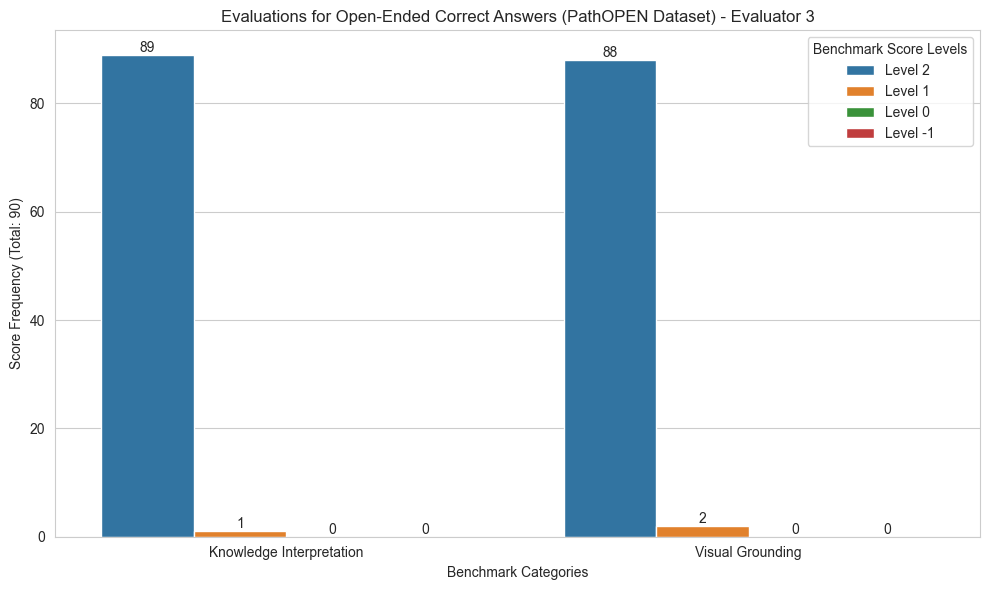

In [16]:
temp_data = correct_answer_eval_data.drop(columns=['Total']).loc['Open-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
plt.title(f'Evaluations for Open-Ended Correct Answers (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answer_total[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_correct_answers.png')
plt.show()


MCQ Correct Answers Graph

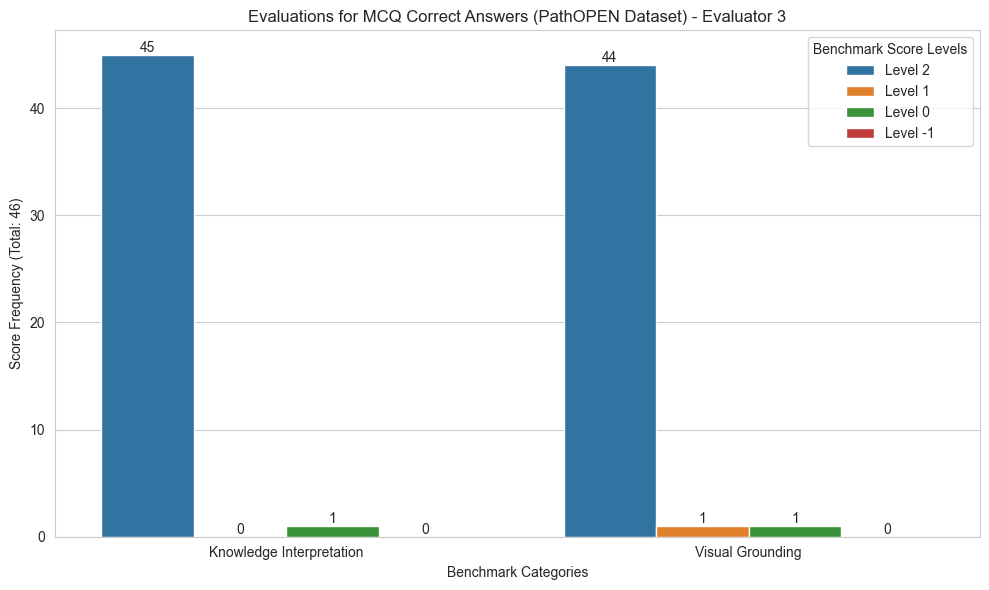

In [17]:
temp_data = correct_answer_eval_data.drop(columns=['Total']).loc['MCQ'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)

plt.title(f'Evaluations for MCQ Correct Answers (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')

plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answer_total[2]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_correct_answers.png')
plt.show()

Close-Ended Correct Answers Graph

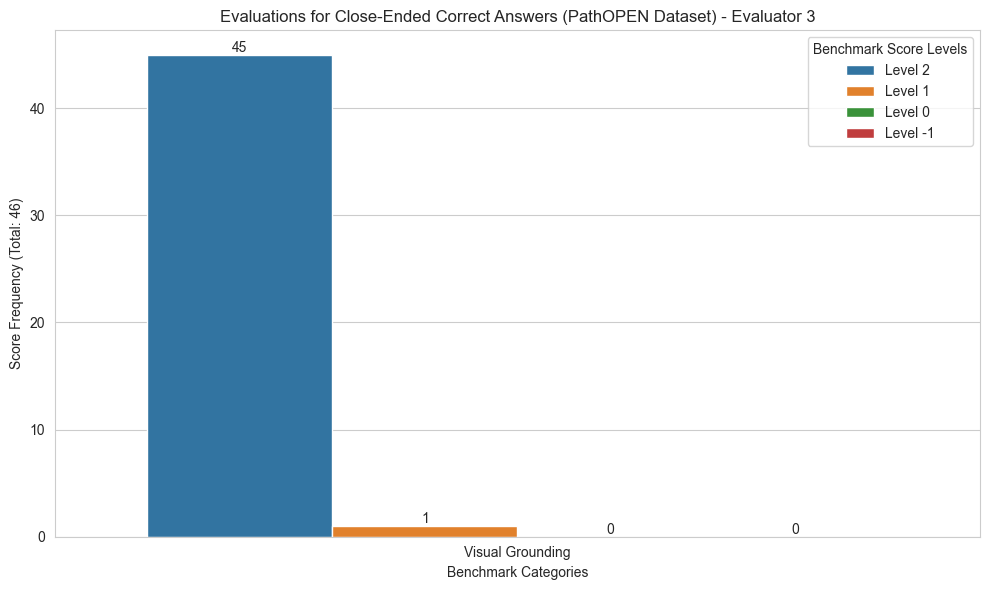

In [18]:
temp_data = correct_answer_eval_data.drop(columns=['Total']).loc['Close-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
    
plt.title(f'Evaluations for Close-Ended Correct Answers (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answer_total[2]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_close_ended_correct_answers.png')
plt.show()

#### Wrong Answer

1

In [19]:
oe_wrong_answer_1_err_prox_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Wrong_Answer_1'].notnull() & eval_data['OE_Wrong_Answer_1_Err_Prox'].notnull()]
oe_wrong_answer_1_err_prox_total = len(oe_wrong_answer_1_err_prox_df)
oe_wrong_answer_1_err_prox_eval_2 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == 2])
oe_wrong_answer_1_err_prox_eval_1 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == 1])
oe_wrong_answer_1_err_prox_eval_0 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == 0])
oe_wrong_answer_1_err_prox_eval_neg_1 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == -1])

In [20]:
oe_wrong_answer_1_vis_ground_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Wrong_Answer_1'].notnull() & eval_data['OE_Wrong_Answer_1_Vis_Ground'].notnull()]
oe_wrong_answer_1_vis_ground_total = len(oe_wrong_answer_1_vis_ground_df)
oe_wrong_answer_1_vis_ground_eval_2 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == 2])
oe_wrong_answer_1_vis_ground_eval_1 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == 1])
oe_wrong_answer_1_vis_ground_eval_0 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == 0])
oe_wrong_answer_1_vis_ground_eval_neg_1 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == -1])

2

In [21]:
oe_wrong_answer_2_err_prox_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Wrong_Answer_2'].notnull() & eval_data['OE_Wrong_Answer_2_Err_Prox'].notnull()]
oe_wrong_answer_2_err_prox_total = len(oe_wrong_answer_2_err_prox_df)
oe_wrong_answer_2_err_prox_eval_2 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == 2])
oe_wrong_answer_2_err_prox_eval_1 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == 1])
oe_wrong_answer_2_err_prox_eval_0 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == 0])
oe_wrong_answer_2_err_prox_eval_neg_1 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == -1])

In [22]:
oe_wrong_answer_2_vis_ground_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Wrong_Answer_2'].notnull() & eval_data['OE_Wrong_Answer_2_Vis_Ground'].notnull()]
oe_wrong_answer_2_vis_ground_total = len(oe_wrong_answer_2_vis_ground_df)
oe_wrong_answer_2_vis_ground_eval_2 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == 2])
oe_wrong_answer_2_vis_ground_eval_1 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == 1])
oe_wrong_answer_2_vis_ground_eval_0 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == 0])
oe_wrong_answer_2_vis_ground_eval_neg_1 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == -1])

MCQ

In [23]:
mcq_wrong_answer_1_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1_Err_Prox'].notnull()]
mcq_wrong_answer_1_err_prox_total = len(mcq_wrong_answer_1_err_prox_df)
mcq_wrong_answer_1_err_prox_eval_2 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == 2])
mcq_wrong_answer_1_err_prox_eval_1 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == 1])
mcq_wrong_answer_1_err_prox_eval_0 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == 0])
mcq_wrong_answer_1_err_prox_eval_neg_1 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == -1])

In [24]:
mcq_wrong_answer_1_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1_Vis_Ground'].notnull()]
mcq_wrong_answer_1_vis_ground_total = len(mcq_wrong_answer_1_vis_ground_df)
mcq_wrong_answer_1_vis_ground_eval_2 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == 2])
mcq_wrong_answer_1_vis_ground_eval_1 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == 1])
mcq_wrong_answer_1_vis_ground_eval_0 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == 0])
mcq_wrong_answer_1_vis_ground_eval_neg_1 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == -1])

In [25]:
mcq_wrong_answer_2_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2_Err_Prox'].notnull()]
mcq_wrong_answer_2_err_prox_total = len(mcq_wrong_answer_2_err_prox_df)
mcq_wrong_answer_2_err_prox_eval_2 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == 2])
mcq_wrong_answer_2_err_prox_eval_1 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == 1])
mcq_wrong_answer_2_err_prox_eval_0 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == 0])
mcq_wrong_answer_2_err_prox_eval_neg_1 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == -1])

In [26]:
mcq_wrong_answer_2_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2_Vis_Ground'].notnull()]
mcq_wrong_answer_2_vis_ground_total = len(mcq_wrong_answer_2_vis_ground_df)
mcq_wrong_answer_2_vis_ground_eval_2 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == 2])
mcq_wrong_answer_2_vis_ground_eval_1 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == 1])
mcq_wrong_answer_2_vis_ground_eval_0 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == 0])
mcq_wrong_answer_2_vis_ground_eval_neg_1 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == -1])

In [27]:
mcq_wrong_answer_3_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3_Err_Prox'].notnull()]
mcq_wrong_answer_3_err_prox_total = len(mcq_wrong_answer_3_err_prox_df)
mcq_wrong_answer_3_err_prox_eval_2 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == 2])
mcq_wrong_answer_3_err_prox_eval_1 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == 1])
mcq_wrong_answer_3_err_prox_eval_0 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == 0])
mcq_wrong_answer_3_err_prox_eval_neg_1 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == -1])

In [28]:
mcq_wrong_answer_3_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3_Vis_Ground'].notnull()]
mcq_wrong_answer_3_vis_ground_total = len(mcq_wrong_answer_3_vis_ground_df)
mcq_wrong_answer_3_vis_ground_eval_2 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == 2])
mcq_wrong_answer_3_vis_ground_eval_1 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == 1])
mcq_wrong_answer_3_vis_ground_eval_0 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == 0])
mcq_wrong_answer_3_vis_ground_eval_neg_1 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == -1])

In [29]:
mcq_wrong_answer_4_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4_Err_Prox'].notnull()]
mcq_wrong_answer_4_err_prox_total = len(mcq_wrong_answer_4_err_prox_df)
mcq_wrong_answer_4_err_prox_eval_2 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == 2])
mcq_wrong_answer_4_err_prox_eval_1 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == 1])
mcq_wrong_answer_4_err_prox_eval_0 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == 0])
mcq_wrong_answer_4_err_prox_eval_neg_1 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == -1])

In [30]:
mcq_wrong_answer_4_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4_Vis_Ground'].notnull()]
mcq_wrong_answer_4_vis_ground_total = len(mcq_wrong_answer_4_vis_ground_df)
mcq_wrong_answer_4_vis_ground_eval_2 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == 2])
mcq_wrong_answer_4_vis_ground_eval_1 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == 1])
mcq_wrong_answer_4_vis_ground_eval_0 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == 0])
mcq_wrong_answer_4_vis_ground_eval_neg_1 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == -1])

Calculating the consolidated information all the wrong questions/answers

In [31]:
wrong_answer_que_type = [
                            'Open-Ended',
                            'Open-Ended',
                            'MCQ',
                            'MCQ'
                        ]


wrong_answer_benchmark_label = [
                                    'Error Proximity',
                                    'Visual Grounding',
                                    'Error Proximity',
                                    'Visual Grounding'
                                ]

wrong_answer_total = [  oe_wrong_answer_1_err_prox_total + oe_wrong_answer_2_err_prox_total,
                        oe_wrong_answer_1_vis_ground_total + oe_wrong_answer_2_vis_ground_total,
                        mcq_wrong_answer_1_err_prox_total + mcq_wrong_answer_2_err_prox_total + mcq_wrong_answer_3_err_prox_total + mcq_wrong_answer_4_err_prox_total,
                        mcq_wrong_answer_1_vis_ground_total + mcq_wrong_answer_2_vis_ground_total + mcq_wrong_answer_3_vis_ground_total + mcq_wrong_answer_4_vis_ground_total
                    ]

wrong_answer_eval_2 = [  oe_wrong_answer_1_err_prox_eval_2 + oe_wrong_answer_2_err_prox_eval_2,
                        oe_wrong_answer_1_vis_ground_eval_2 + oe_wrong_answer_2_vis_ground_eval_2,
                        mcq_wrong_answer_1_err_prox_eval_2 + mcq_wrong_answer_2_err_prox_eval_2 + mcq_wrong_answer_3_err_prox_eval_2 + mcq_wrong_answer_4_err_prox_eval_2,
                        mcq_wrong_answer_1_vis_ground_eval_2 + mcq_wrong_answer_2_vis_ground_eval_2 + mcq_wrong_answer_3_vis_ground_eval_2 + mcq_wrong_answer_4_vis_ground_eval_2
                    ]

wrong_answer_eval_1 = [  oe_wrong_answer_1_err_prox_eval_1 + oe_wrong_answer_2_err_prox_eval_1,
                        oe_wrong_answer_1_vis_ground_eval_1 + oe_wrong_answer_2_vis_ground_eval_1,
                        mcq_wrong_answer_1_err_prox_eval_1 + mcq_wrong_answer_2_err_prox_eval_1 + mcq_wrong_answer_3_err_prox_eval_1 + mcq_wrong_answer_4_err_prox_eval_1,
                        mcq_wrong_answer_1_vis_ground_eval_1 + mcq_wrong_answer_2_vis_ground_eval_1 + mcq_wrong_answer_3_vis_ground_eval_1 + mcq_wrong_answer_4_vis_ground_eval_1
                    ]

wrong_answer_eval_0 = [  oe_wrong_answer_1_err_prox_eval_0 + oe_wrong_answer_2_err_prox_eval_0,
                        oe_wrong_answer_1_vis_ground_eval_0 + oe_wrong_answer_2_vis_ground_eval_0,
                        mcq_wrong_answer_1_err_prox_eval_0 + mcq_wrong_answer_2_err_prox_eval_0 + mcq_wrong_answer_3_err_prox_eval_0 + mcq_wrong_answer_4_err_prox_eval_0,
                        mcq_wrong_answer_1_vis_ground_eval_0 + mcq_wrong_answer_2_vis_ground_eval_0 + mcq_wrong_answer_3_vis_ground_eval_0 + mcq_wrong_answer_4_vis_ground_eval_0
                    ]

wrong_answer_eval_neg_1 = [  oe_wrong_answer_1_err_prox_eval_neg_1 + oe_wrong_answer_2_err_prox_eval_neg_1,
                            oe_wrong_answer_1_vis_ground_eval_neg_1 + oe_wrong_answer_2_vis_ground_eval_neg_1,
                            mcq_wrong_answer_1_err_prox_eval_neg_1 + mcq_wrong_answer_2_err_prox_eval_neg_1 + mcq_wrong_answer_3_err_prox_eval_neg_1 + mcq_wrong_answer_4_err_prox_eval_neg_1,
                            mcq_wrong_answer_1_vis_ground_eval_neg_1 + mcq_wrong_answer_2_vis_ground_eval_neg_1 + mcq_wrong_answer_3_vis_ground_eval_neg_1 + mcq_wrong_answer_4_vis_ground_eval_neg_1
                        ]

wrong_answer_eval_data = pd.DataFrame({ 'Total': wrong_answer_total,
                                        'Level 2': wrong_answer_eval_2,
                                        'Level 1': wrong_answer_eval_1,
                                        'Level 0': wrong_answer_eval_0,
                                        'Level -1': wrong_answer_eval_neg_1}, index=[wrong_answer_que_type, wrong_answer_benchmark_label])

wrong_answer_eval_data

Total  Level 2  Level 1  Level 0  Level -1
Open-Ended Error Proximity      68        0       49       19         0
           Visual Grounding     68        5       38       25         0
MCQ        Error Proximity     184        2       67      115         0
           Visual Grounding    184        4       39      141         0

Save the Evaluation Data for correct answers

In [32]:
wrong_answer_eval_data.to_pickle(os.path.join(output_data_path, 'pathopen_wrong_answer_eval_data.pkl'))

Open-Ended Wrong Answers Graph

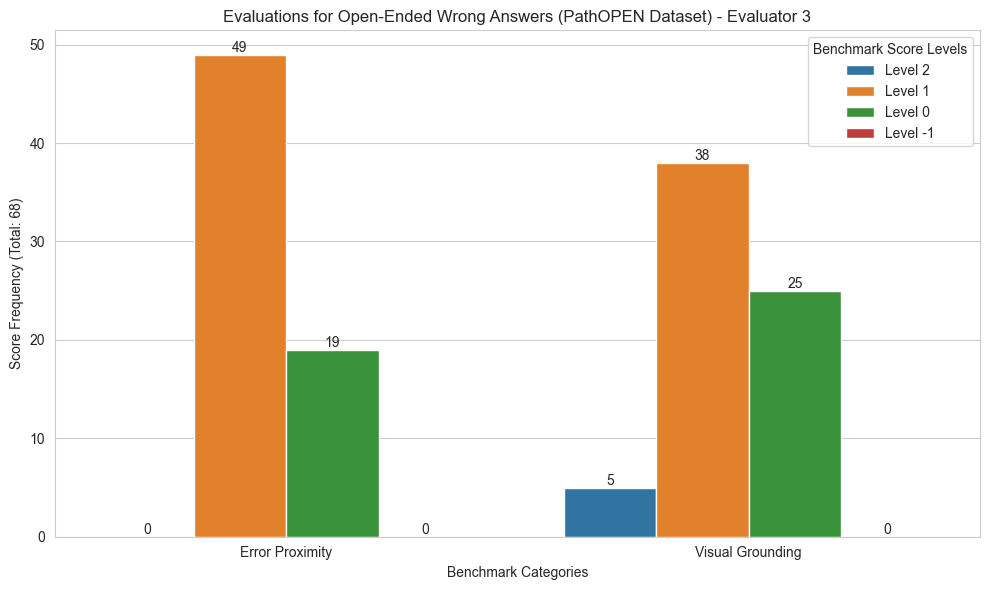

In [33]:
temp_data = wrong_answer_eval_data.drop(columns=['Total']).loc['Open-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
    
plt.title(f'Evaluations for Open-Ended Wrong Answers (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {wrong_answer_total[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_wrong_answers.png')
plt.show()

MCQ Wrong Answers Graph

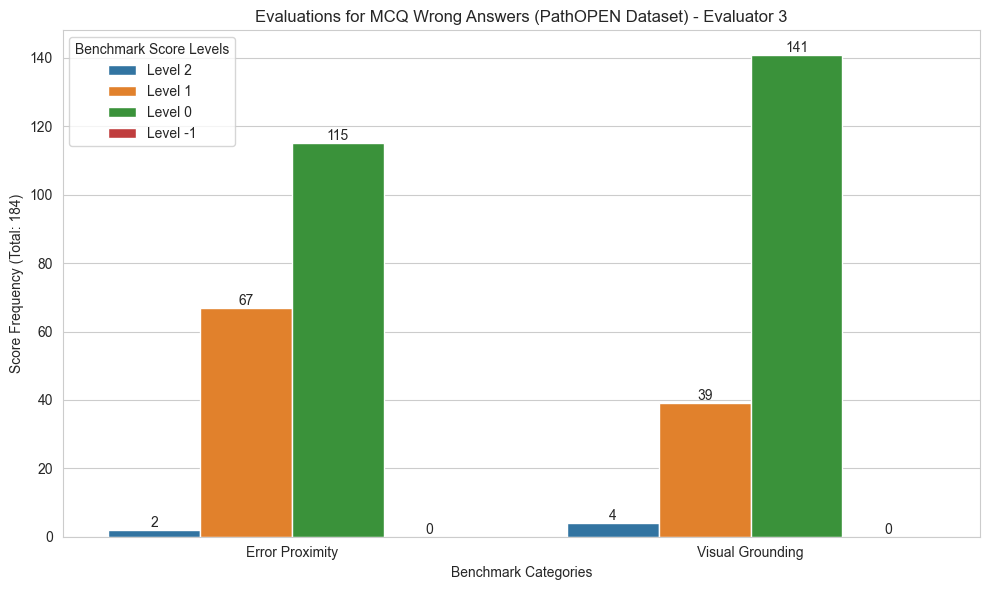

In [34]:
temp_data = wrong_answer_eval_data.drop(columns=['Total']).loc['MCQ'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)

plt.title(f'Evaluations for MCQ Wrong Answers (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {wrong_answer_total[2]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_wrong_answers.png')
plt.show()